In [1]:
# Step 1: Upload the file in Colab (run this cell first)
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
file_name = list(uploaded.keys())[0]  # Gets 'US-Retail-Data.xlsx'

# Step 2: Load the dataset
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

# Step 3: Basic structure checks
print("Dataset dimensions:", df.shape)
print("\nVariable names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows (head):")
print(df.head())
print("\nLast 5 rows (tail):")
print(df.tail())

# Optional: Basic info
print("\nDataset info:")
print(df.info())

Saving Asset_Returns_Data.xlsx to Asset_Returns_Data.xlsx
Dataset dimensions: (3147, 8)

Variable names:
['Dates', 'US sovereign CDS', 'UK Sovereign CDS', 'German Sovereign CDS', 'Silver', 'Copper', 'Bitcoin', 'Gold']

Data types:
Dates                   datetime64[ns]
US sovereign CDS               float64
UK Sovereign CDS               float64
German Sovereign CDS           float64
Silver                         float64
Copper                         float64
Bitcoin                        float64
Gold                           float64
dtype: object

First 5 rows (head):
       Dates  US sovereign CDS  UK Sovereign CDS  German Sovereign CDS  \
0 2014-01-02            -0.716            -0.716                -0.389   
1 2014-01-03            -1.449            -1.449                 0.389   
2 2014-01-06             0.190             0.190                -0.389   
3 2014-01-07            -0.408            -0.408                -0.276   
4 2014-01-08             0.099             0.099   

Numeric columns for EDA: ['US sovereign CDS', 'UK Sovereign CDS', 'German Sovereign CDS', 'Silver', 'Copper', 'Bitcoin', 'Gold']
Number of observations: 3147

Summary Statistics:
       US sovereign CDS  UK Sovereign CDS  German Sovereign CDS       Silver  \
count       3147.000000       3147.000000           3147.000000  3147.000000   
mean          -0.003890         -0.003890             -0.005576     0.023476   
std            0.777541          0.777541              0.534254     0.459003   
min          -25.272000        -25.272000             -5.033000    -3.780000   
25%            0.000000          0.000000             -0.198000    -0.150000   
50%            0.000000          0.000000              0.000000     0.000000   
75%            0.000000          0.000000              0.153000     0.180000   
max           14.734000         14.734000              5.848000     5.930000   

            Copper       Bitcoin         Gold  
count  3147.000000   3147.000000  3147.000000  
mean

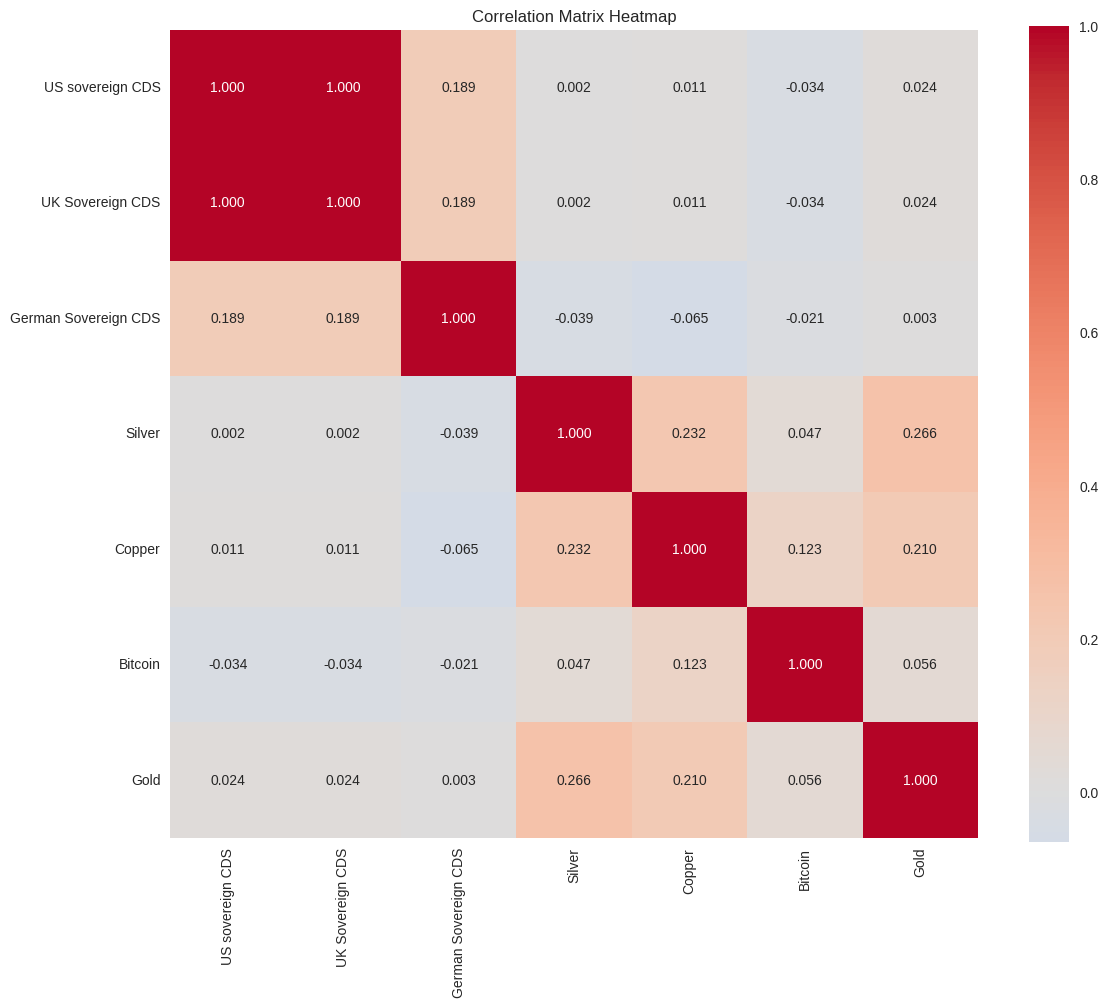

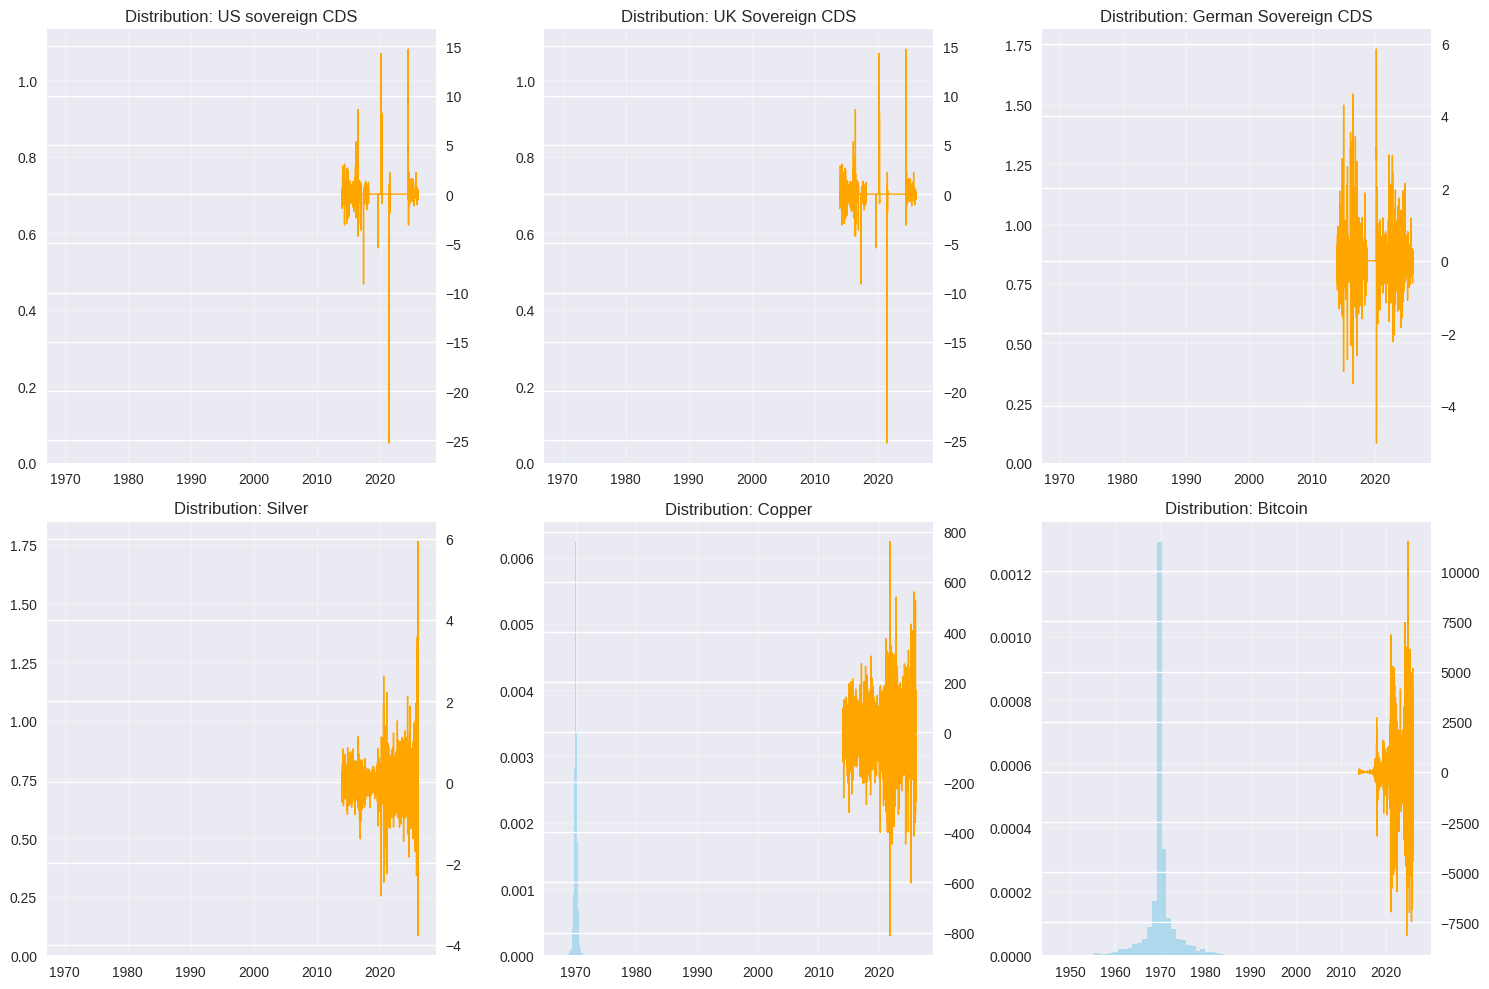


Rolling Statistics Preview (last 5 rows, 30-day window):
                       mean                                                  \
           US sovereign CDS UK Sovereign CDS German Sovereign CDS    Silver   
Dates                                                                         
2026-01-19        -0.051767        -0.051767            -0.006267  1.154333   
2026-01-20        -0.048800        -0.048800            -0.012900  1.235667   
2026-01-21        -0.045833        -0.045833            -0.014100  1.127333   
2026-01-22        -0.061900        -0.061900            -0.014667  1.042167   
2026-01-23        -0.067800        -0.067800            -0.015533  0.962333   

                                                          std  \
               Copper     Bitcoin       Gold US sovereign CDS   
Dates                                                           
2026-01-19  46.312000   53.722000  16.007667         0.234580   
2026-01-20  45.611333 -109.892667  18.506333     

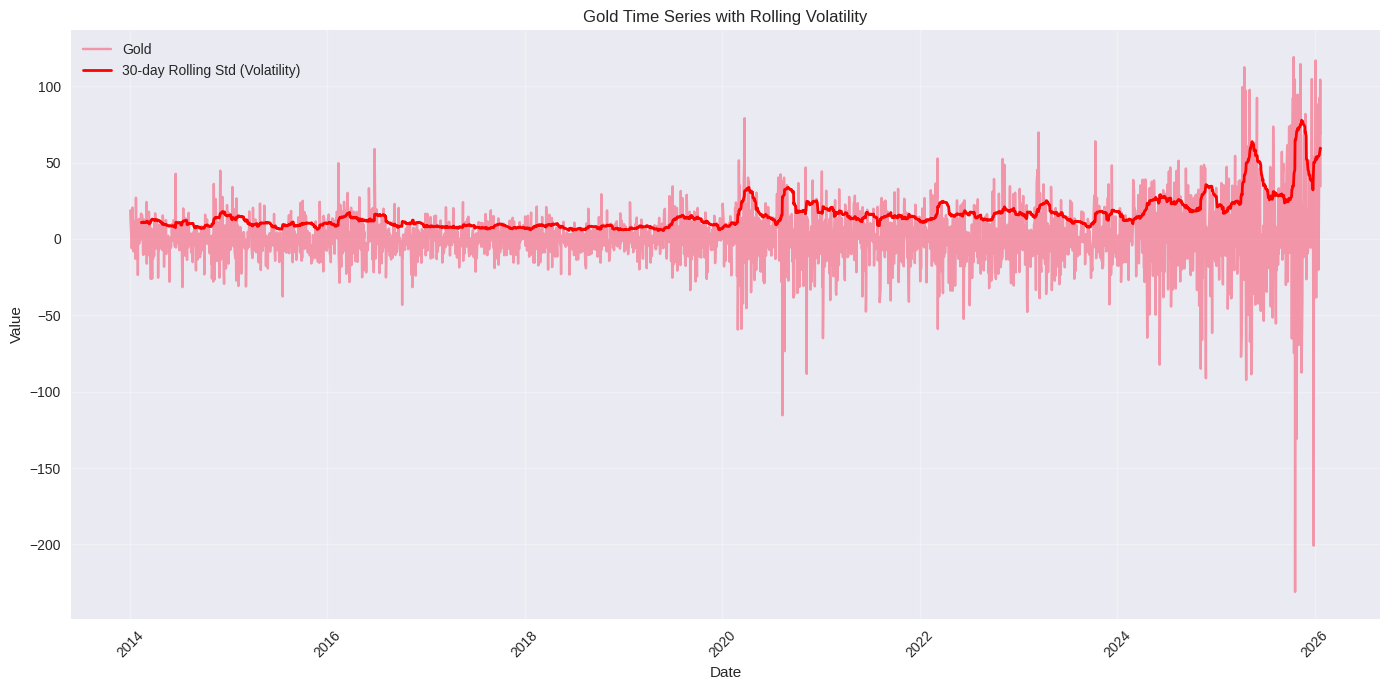


EDA complete. Key insights: Check outputs above for outliers, correlations, distributions, rolling stats.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Assume df is loaded with 'Date' as first column; convert to datetime if needed
if 'Dates' in df.columns:
    df['Dates'] = pd.to_datetime(df['Dates'])
    df.set_index('Dates', inplace=True)

# Select numeric columns (exclude Date if index)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric columns for EDA:", numeric_cols)
print(f"Number of observations: {len(df)}")

# 1. Summary statistics (for reference)
print("\nSummary Statistics:")
print(df[numeric_cols].describe())

# 2. Outlier detection using IQR method
print("\nOutlier Detection (IQR method):")
outliers = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outliers[col] = {'outliers': outlier_count, 'lower': lower_bound, 'upper': upper_bound}
    print(f"{col}: {outlier_count} outliers (bounds: [{lower_bound:.4f}, {upper_bound:.4f}])")

# 3. Correlation matrix and heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True, fmt='.3f')
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

# 4. Distribution plots: Histograms + KDE for key variables (first 6 numerics for brevity)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
for i, col in enumerate(numeric_cols[:6]):
    axes[i].hist(df[col], bins=50, alpha=0.6, density=True, color='skyblue')
    axes[i].twinx().plot(df[col], color='orange', linestyle='-', linewidth=1)
    axes[i].set_title(f'Distribution: {col}')
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Rolling statistics (30-day window: mean, std for volatility)
print("\nRolling Statistics Preview (last 5 rows, 30-day window):")
rolling_mean = df[numeric_cols].rolling(window=30).mean()
rolling_std = df[numeric_cols].rolling(window=30).std()
rolling_df = pd.concat([rolling_mean, rolling_std], axis=1, keys=['mean', 'std'])
print(rolling_df.tail())

# Plot example time-series with rolling std for volatility (e.g., Gold)
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Gold'], label='Gold', alpha=0.7)
plt.plot(rolling_std['Gold'], label='30-day Rolling Std (Volatility)', color='red', linewidth=2)
plt.title('Gold Time Series with Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nEDA complete. Key insights: Check outputs above for outliers, correlations, distributions, rolling stats.")

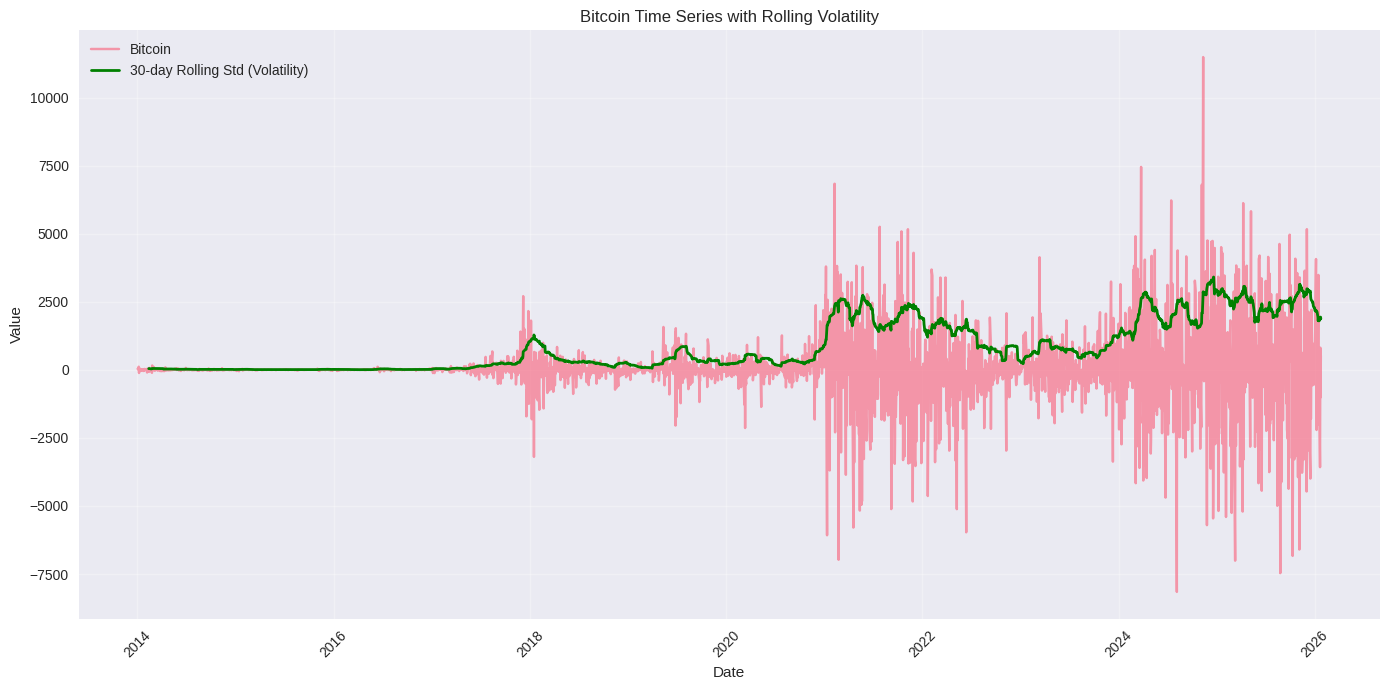

In [4]:
# Plot time-series with rolling std for volatility for Bitcoin
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Bitcoin'], label='Bitcoin', alpha=0.7)
plt.plot(rolling_std['Bitcoin'], label='30-day Rolling Std (Volatility)', color='green', linewidth=2)
plt.title('Bitcoin Time Series with Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

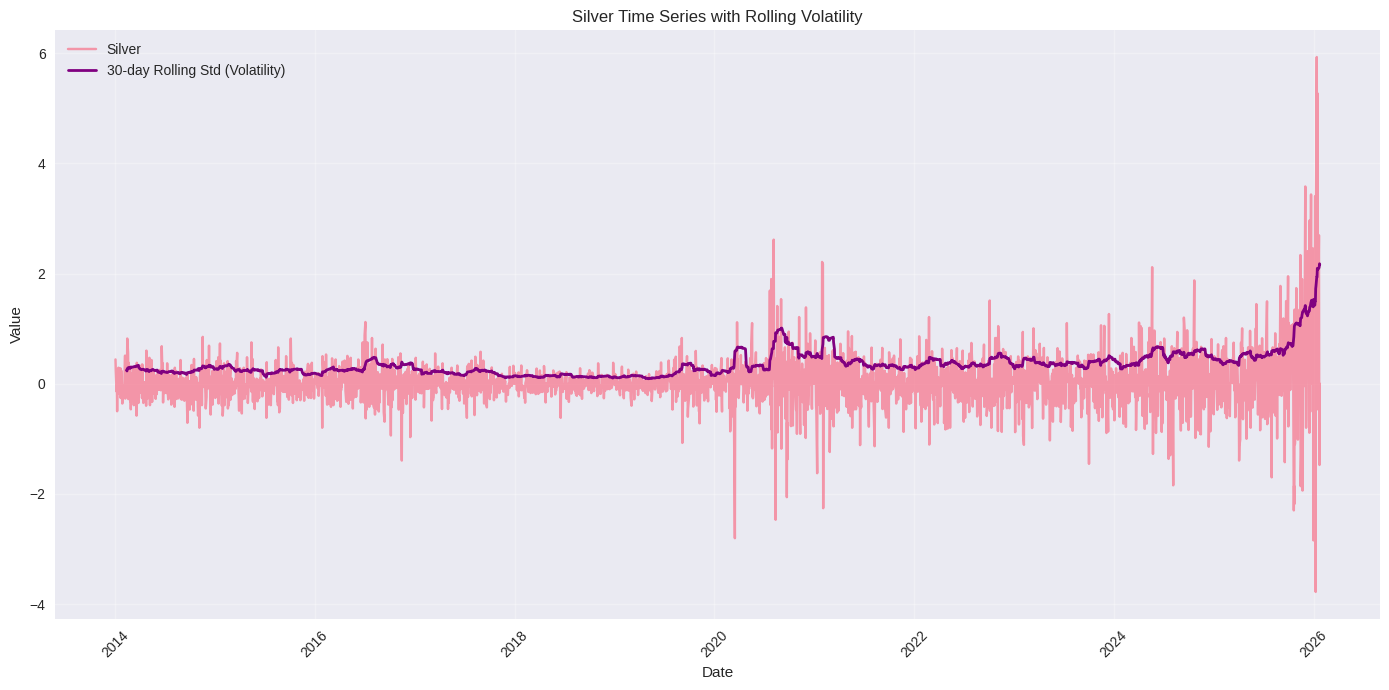

In [5]:
# Plot time-series with rolling std for volatility for Silver
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Silver'], label='Silver', alpha=0.7)
plt.plot(rolling_std['Silver'], label='30-day Rolling Std (Volatility)', color='purple', linewidth=2)
plt.title('Silver Time Series with Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

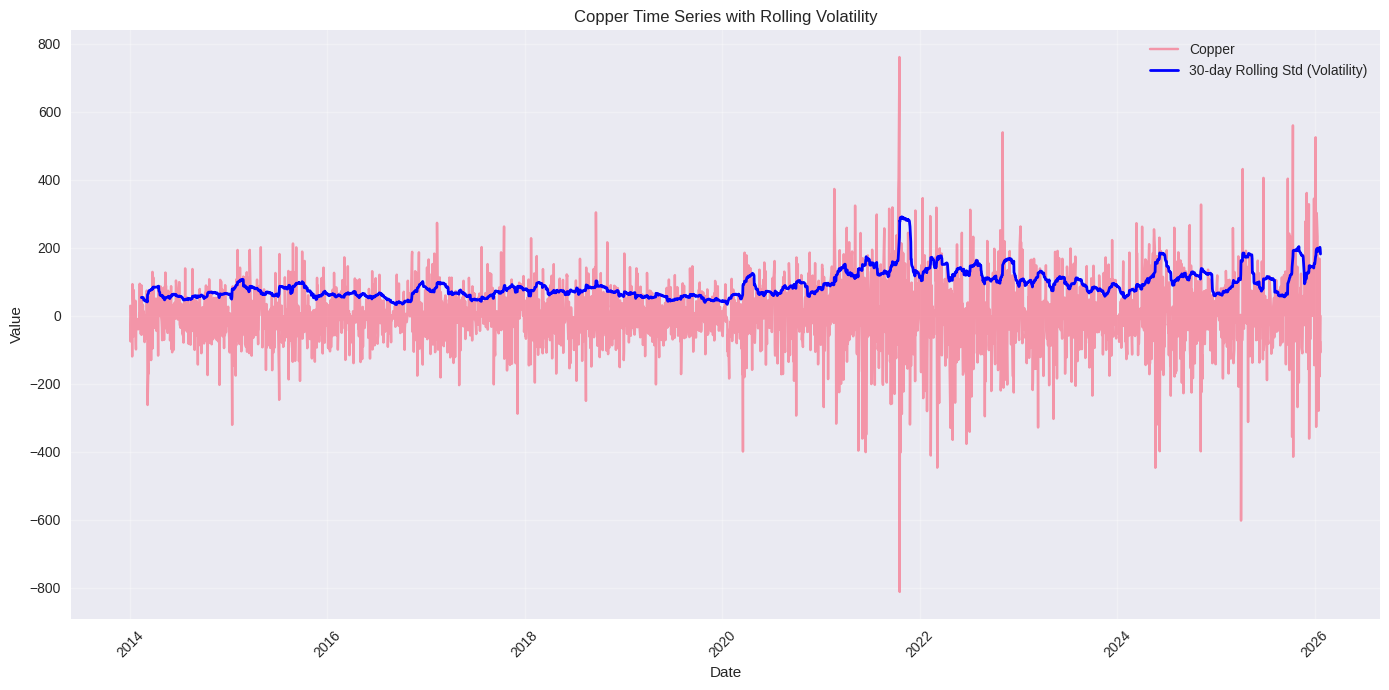

In [6]:
# Plot time-series with rolling std for volatility for Copper
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Copper'], label='Copper', alpha=0.7)
plt.plot(rolling_std['Copper'], label='30-day Rolling Std (Volatility)', color='blue', linewidth=2)
plt.title('Copper Time Series with Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
import statsmodels.api as sm
!pip install ruptures
from ruptures import Pelt  # For Chow-like structural break detection

# Rename columns to match user spec (from data: US sovereign CDS, UK Sovereign CDS, German Sovereign CDS, Silver, Copper, Bitcoin, Gold)
var_map = {
    'US sovereign CDS': 'US Sovereign CDS',
    'UK Sovereign CDS': 'UK Sovereign CDS',
    'German Sovereign CDS': 'German Sovereign CDS',
    'Silver': 'Silver',
    'Copper': 'Copper',
    'Bitcoin': 'Bitcoin',
    'Gold': 'Gold'

}
initial_test_vars = ['US Sovereign CDS', 'UK Sovereign CDS', 'German Sovereign CDS', 'Silver', 'Copper', 'Bitcoin', 'Gold']

# Identify the actual column names from `df` that correspond to the user's desired names
actual_df_cols_to_use = []
for desired_name in initial_test_vars:
    if desired_name in var_map and var_map[desired_name] in df.columns:
        actual_df_cols_to_use.append(var_map[desired_name])
    else:
        print(f"Warning: Variable '{desired_name}' not found in the dataset or its mapping.")

if not actual_df_cols_to_use:
    print("Error: No valid columns found in the dataset to perform tests.")
    # Initialize df_renamed as empty if no columns are found, to prevent further NameErrors
    df_renamed = pd.DataFrame()
else:
    # Create df_renamed by selecting the actual columns from df
    df_renamed = df[actual_df_cols_to_use].copy()

    # Create a map to rename the columns in df_renamed from their actual names to the desired user-friendly names
    rename_to_user_spec = {v: k for k, v in var_map.items() if v in actual_df_cols_to_use}
    df_renamed.rename(columns=rename_to_user_spec, inplace=True)

# Update test_vars to reflect the columns actually used (now with user-friendly names)
test_vars = list(df_renamed.columns)


if not df_renamed.empty:
    print("Testing on:", test_vars)
    print("Alpha = 0.05\n")

    # 1. Normality Tests: KS (vs normal), AD (Anderson-Darling)
    print("1. NORMALLITY TESTS")
    for col in df_renamed.columns:
        data = df_renamed[col].dropna()
        # KS test
        ks_stat, ks_p = stats.kstest(data, 'norm', args=(np.mean(data), np.std(data)))
        print(f"{col} KS test: stat={ks_stat:.4f}, p={ks_p:.4f} {'REJECT' if ks_p < 0.05 else 'FAIL TO REJECT'} normality")
        # AD test
        ad_result = stats.anderson(data, dist='norm')
        ad_p = ad_result.significance_level[2] / 100  # Approx p for 5%
        print(f"{col} AD test: stat={ad_result.statistic:.4f}, crit_5%={ad_result.critical_values[2]:.4f} {'REJECT' if ad_result.statistic > ad_result.critical_values[2] else 'FAIL TO REJECT'} normality")
    print()

    # 2. Stationarity: ADF (H0: unit root), KPSS (H0: stationary)
    print("2. STATIONARITY TESTS")
    for col in df_renamed.columns:
        data = df_renamed[col].dropna()
        # ADF
        adf_res = adfuller(data)
        print(f"{col} ADF: stat={adf_res[0]:.4f}, p={adf_res[1]:.4f} {'REJECT unit root (stationary)' if adf_res[1] < 0.05 else 'FAIL TO REJECT (non-stationary)'}")
        # KPSS
        kpss_res = kpss(data)
        print(f"{col} KPSS: stat={kpss_res[0]:.4f}, p={kpss_res[1]:.4f} {'REJECT stationary (non-stat)' if kpss_res[1] < 0.05 else 'FAIL TO REJECT (stationary)'}")
    print()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.9 MB/s eta 0:00:00
Testing on: ['UK Sovereign CDS', 'German Sovereign CDS', 'Silver', 'Copper', 'Bitcoin', 'Gold']
Alpha = 0.05

1. NORMALLITY TESTS
UK Sovereign CDS KS test: stat=0.3136, p=0.0000 REJECT normality
UK Sovereign CDS AD test: stat=636.2456, crit_5%=0.7860 REJECT normality
German Sovereign CDS KS test: stat=0.1362, p=0.0000 REJECT normality
German Sovereign CDS AD test: stat=135.7709, crit_5%=0.7860 REJECT normality
Silver KS test: stat=0.1222, p=0.0000 REJECT normality
Silver AD test: stat=113.4787, crit_5%=0.7860 REJECT normality
Copper KS test: stat=0.0651, p=0.0000 REJECT normality
Copper AD test: stat=32.2627, crit_5%=0.7860 REJECT normality
Bitcoin KS test: stat=0.2084, p=0.0000 REJECT normality
Bitcoin AD test: stat=275.1584, crit_5%=0.7860 REJECT normality
Gold KS test: stat=0.1075, p=0.0000 REJECT normality
Gold AD test: stat=90.4828, crit_5%=0.7860 REJECT normality

2. STATIONARITY TESTS
UK Sovereign CDS A

/tmp/ipython-input-4032492923.py:69: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(data)


German Sovereign CDS ADF: stat=-15.0188, p=0.0000 REJECT unit root (stationary)
German Sovereign CDS KPSS: stat=0.0398, p=0.1000 FAIL TO REJECT (stationary)


/tmp/ipython-input-4032492923.py:69: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(data)


Silver ADF: stat=-3.9138, p=0.0019 REJECT unit root (stationary)
Silver KPSS: stat=1.3295, p=0.0100 REJECT stationary (non-stat)


...

/tmp/ipython-input-4032492923.py:69: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(data)


Bitcoin ADF: stat=-9.4601, p=0.0000 REJECT unit root (stationary)
Bitcoin KPSS: stat=0.1470, p=0.1000 FAIL TO REJECT (stationary)


/tmp/ipython-input-4032492923.py:69: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(data)


Gold ADF: stat=-6.5442, p=0.0000 REJECT unit root (stationary)
Gold KPSS: stat=1.8638, p=0.0100 REJECT stationary (non-stat)



/tmp/ipython-input-4032492923.py:69: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(data)


In [11]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan  # For reference

# Ensure columns exist (rename if needed from original)
col_map = {
    'US sovereign CDS': 'US Sovereign CDS',
    'UK Sovereign CDS': 'UK Sovereign CDS',
    'German Sovereign CDS': 'German Sovereign CDS',
    'Silver': 'Silver',
    'Copper': 'Copper',
    'Bitcoin': 'Bitcoin',
    'Gold': 'Gold'
}
df_model = df.rename(columns=col_map).dropna(subset=['Bitcoin'])  # Base clean

print("Model dataset shape after NA drop on dep var:", df_model.shape)
print("Columns used:", list(col_map.values()))

# Model 1: Contemporaneous vars
dep = 'Bitcoin'
indeps1 = ['US Sovereign CDS', 'Silver', 'Gold']
X1 = sm.add_constant(df_model[indeps1])
y1 = df_model[dep]
model1 = sm.OLS(y1, X1).fit(cov_type='HC3')  # Robust HC3 SE
print("\n=== MODEL 1: Contemporaneous ===")
print(model1.summary())


print("\nModels fitted. Check summaries for coefficients, p-values, robust SE.")

Model dataset shape after NA drop on dep var: (3147, 7)
Columns used: ['US Sovereign CDS', 'UK Sovereign CDS', 'German Sovereign CDS', 'Silver', 'Copper', 'Bitcoin', 'Gold']

=== MODEL 1: Contemporaneous ===
                            OLS Regression Results                            
Dep. Variable:                Bitcoin   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.679
Date:                Fri, 13 Feb 2026   Prob (F-statistic):              0.169
Time:                        04:45:37   Log-Likelihood:                -26898.
No. Observations:                3147   AIC:                         5.380e+04
Df Residuals:                    3143   BIC:                         5.383e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
  

In [12]:
# Step 1: Upload the file in Colab (run this cell first)
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
file_name = list(uploaded.keys())[0]  # Gets 'US-Retail-Data.xlsx'

# Step 2: Load the dataset
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

# Step 3: Basic structure checks
print("Dataset dimensions:", df.shape)
print("\nVariable names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows (head):")
print(df.head())
print("\nLast 5 rows (tail):")
print(df.tail())

# Optional: Basic info
print("\nDataset info:")
print(df.info())

Saving Asset_returns_Lag.xlsx to Asset_returns_Lag.xlsx
Dataset dimensions: (3145, 8)

Variable names:
['Dates', 'US sovereign CDS', 'UK Sovereign CDS', 'German Sovereign CDS', 'Silver', 'Copper', 'Gold', 'Bitcoin']

Data types:
Dates                   datetime64[ns]
US sovereign CDS               float64
UK Sovereign CDS               float64
German Sovereign CDS           float64
Silver                         float64
Copper                         float64
Gold                           float64
Bitcoin                        float64
dtype: object

First 5 rows (head):
       Dates  US sovereign CDS  UK Sovereign CDS  German Sovereign CDS  \
0 2014-01-03            -1.449            -1.449                 0.389   
1 2014-01-06             0.190             0.190                -0.389   
2 2014-01-07            -0.408            -0.408                -0.276   
3 2014-01-08             0.099             0.099                -0.806   
4 2014-01-09            -0.293            -0.293     

In [13]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan  # For reference

# Ensure columns exist (rename if needed from original)
col_map = {
    'US sovereign CDS': 'US Sovereign CDS',
    'UK Sovereign CDS': 'UK Sovereign CDS',
    'German Sovereign CDS': 'German Sovereign CDS',
    'Silver': 'Silver',
    'Copper': 'Copper',
    'Bitcoin': 'Bitcoin',
    'Gold': 'Gold'
}
df_model = df.rename(columns=col_map).dropna(subset=['Bitcoin'])  # Base clean

print("Model dataset shape after NA drop on dep var:", df_model.shape)
print("Columns used:", list(col_map.values()))

# Model 1: Contemporaneous vars
dep = 'Bitcoin'
indeps1 = ['US Sovereign CDS', 'Silver', 'Gold']
X1 = sm.add_constant(df_model[indeps1])
y1 = df_model[dep]
model1 = sm.OLS(y1, X1).fit(cov_type='HC3')  # Robust HC3 SE
print("\n=== MODEL 1: Contemporaneous ===")
print(model1.summary())


print("\nModels fitted. Check summaries for coefficients, p-values, robust SE.")

Model dataset shape after NA drop on dep var: (3145, 8)
Columns used: ['US Sovereign CDS', 'UK Sovereign CDS', 'German Sovereign CDS', 'Silver', 'Copper', 'Bitcoin', 'Gold']

=== MODEL 1: Contemporaneous ===
                            OLS Regression Results                            
Dep. Variable:                Bitcoin   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     6.965
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           0.000114
Time:                        04:50:02   Log-Likelihood:                -26870.
No. Observations:                3145   AIC:                         5.375e+04
Df Residuals:                    3141   BIC:                         5.377e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
  

1. MULTICOLLINEARITY (VIF)

Model 1 VIF:
           Variable   VIF
0             const  1.01
1  US Sovereign CDS  1.00
2            Silver  1.08
3              Gold  1.08
High VIF (>5): None

2. HETEROSKEDASTICITY TESTS (alpha=0.05)
Model 1: BP LM=10.30, p=0.0162 REJECT homo | White LM=52.76, p=0.0000 REJECT homo

3. AUTOCORRELATION TESTS
Model 1: DW=2.081 OK (~2) | LB p-max10=0.0627 Autocorr present


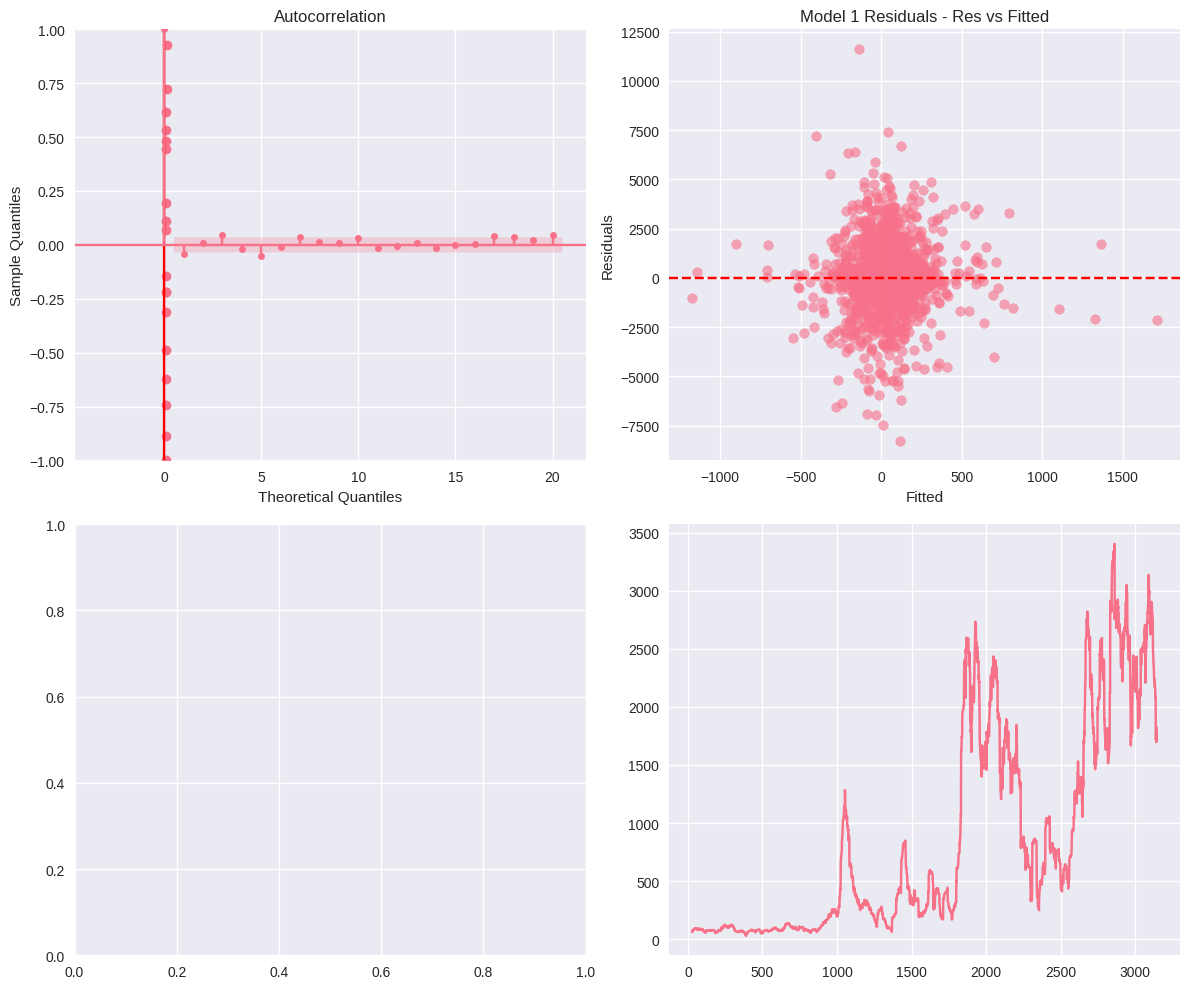


Diagnostics complete. Review VIF<10 OK, hetero/autocorr if p<0.05 issue.


In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson # Corrected import path
import numpy as np
import matplotlib.pyplot as plt

# 1. Multicollinearity: VIF for each model (VIF>5-10 problematic)
print("1. MULTICOLLINEARITY (VIF)")
for i, model in enumerate([model1], 1):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = model.model.exog_names
    vif_data["VIF"] = [variance_inflation_factor(model.model.exog, j) for j in range(model.model.exog.shape[1])]
    print(f"\nModel {i} VIF:")
    print(vif_data.round(2))
    high_vif = vif_data[vif_data['VIF'] > 5]['Variable'].tolist()
    print(f"High VIF (>5): {high_vif if high_vif else 'None'}")

# 2. Heteroskedasticity on residuals
print("\n2. HETEROSKEDASTICITY TESTS (alpha=0.05)")
for i, model in enumerate([model1], 1):
    resid = model.resid
    exog = model.model.exog
    # BP
    bp = het_breuschpagan(resid, exog)
    # White
    white = het_white(resid, exog)
    print(f"Model {i}: BP LM={bp[0]:.2f}, p={bp[1]:.4f} {'REJECT homo' if bp[1]<0.05 else 'Homoosk OK'} | White LM={white[0]:.2f}, p={white[1]:.4f} {'REJECT homo' if white[1]<0.05 else 'Homoosk OK'}")

# 3. Autocorrelation
print("\n3. AUTOCORRELATION TESTS")
for i, model in enumerate([model1], 1):
    resid = model.resid
    dw = durbin_watson(resid)
    lb = acorr_ljungbox(resid, lags=10, return_df=True)
    print(f"Model {i}: DW={dw:.3f} {'OK (~2)' if 1.5<dw<2.5 else 'Autocorr issue'} | LB p-max10={lb['lb_pvalue'].max():.4f} {'No autocorr' if lb['lb_pvalue'].min()>0.05 else 'Autocorr present'}")

# 4. Residual plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models = [model1]
titles = ['Model 1 Residuals', 'Model 2 Residuals']
for j, (model, title) in enumerate(zip(models, titles)):
    resid = model.resid
    # QQ plot
    sm.qqplot(resid, line='s', ax=axes[j, 0])
    axes[j, 0].set_title(f'{title} - QQ Plot')
    # Residuals vs fitted
    axes[j, 1].scatter(model.fittedvalues, resid, alpha=0.6)
    axes[j, 1].axhline(0, color='red', ls='--')
    axes[j, 1].set_xlabel('Fitted')
    axes[j, 1].set_ylabel('Residuals')
    axes[j, 1].set_title(f'{title} - Res vs Fitted')
    # ACF residuals
    from statsmodels.graphics.tsaplots import plot_acf
    plot_acf(resid, lags=20, ax=axes[j%2, 0])  # Reuse axes carefully
    # Rolling resid std
    axes[1, 1].plot(pd.Series(resid).rolling(30).std())  # Example
plt.tight_layout()
plt.show()

print("\nDiagnostics complete. Review VIF<10 OK, hetero/autocorr if p<0.05 issue.")

In [15]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan  # For reference

# Ensure columns exist (rename if needed from original)
col_map = {
    'US sovereign CDS': 'US Sovereign CDS',
    'UK Sovereign CDS': 'UK Sovereign CDS',
    'German Sovereign CDS': 'German Sovereign CDS',
    'Silver': 'Silver',
    'Copper': 'Copper',
    'Bitcoin': 'Bitcoin',
    'Gold': 'Gold'
}
df_model3 = df.rename(columns=col_map).dropna(subset=['Bitcoin'])  # Base clean

print("Model dataset shape after NA drop on dep var:", df_model3.shape)
print("Columns used:", list(col_map.values()))

# Model 1: Contemporaneous vars
dep = 'Bitcoin'
indeps1 = ['Copper', 'Silver', 'Gold']
X1 = sm.add_constant(df_model3[indeps1])
y1 = df_model3[dep]
model3 = sm.OLS(y1, X1).fit(cov_type='HC3')  # Robust HC3 SE
print("\n=== MODEL 3: Contemporaneous ===")
print(model3.summary())


print("\nModels fitted. Check summaries for coefficients, p-values, robust SE.")

Model dataset shape after NA drop on dep var: (3145, 8)
Columns used: ['US Sovereign CDS', 'UK Sovereign CDS', 'German Sovereign CDS', 'Silver', 'Copper', 'Bitcoin', 'Gold']

=== MODEL 3: Contemporaneous ===
                            OLS Regression Results                            
Dep. Variable:                Bitcoin   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     7.606
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           4.58e-05
Time:                        04:59:42   Log-Likelihood:                -26869.
No. Observations:                3145   AIC:                         5.375e+04
Df Residuals:                    3141   BIC:                         5.377e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
  